# Gravitational Sonar 56 — oracle-controlled recovery of Peters–Mathews amplitude

The dissipative model is deliberately minimal:

$$
\left(\frac{dp_\phi}{d\tau}\right)_{\rm diss}=A r^{-7/2}.
$$

The radial law is fixed; Sonar learns only its physical amplitude $A$.

1. **Oracle control:** freeze exact Kerr + exact IC and verify that the scalar search recovers the injected $A$.
2. **Adiabatic calibration:** select the longest acceptable $A=0$ window from 50, 100, 150, and 200 samples.
3. **Conservative stage:** set $A=0$ and fit only a bound-energy initial condition and the metric; reject nonconverged, plunging, or escaping solutions.
4. **Dissipative stage:** freeze the learned metric and IC, fit only $A$, and compare its profile directly with the oracle profile.
5. **Joint polish:** unfreeze all parameters for 15 LM evaluations and accept the result only when it remains physical and improves the full loss.


## Setup

In [1]:
# Colab already ships JAX and SciPy; no optimizer patch is needed for LM.

In [2]:
import math
import os
import time
from pathlib import Path

import jax
jax.config.update("jax_enable_x64", True)  # needed by the LM handoff
import jax.numpy as jnp
from jax import lax, random, tree_util
from jax.flatten_util import ravel_pytree
import matplotlib.pyplot as plt
import numpy as np
from scipy import optimize

print("JAX:", jax.__version__)
print("Devices:", jax.devices())
if jax.default_backend() == "cpu":
    print("WARNING: CPU backend. In Colab select Runtime > Change runtime type > GPU.")

Array = jax.Array

JAX: 0.11.1
Devices: [CudaDevice(id=0)]


## Data and physical inputs

In [3]:
DATA_DIR = Path("/content")
FILE_TAG = "Kerr_rp10_ra14noise0.0_massRatio1000.0spin_0.9inclination_0.7853981633974483_time1260_observertheta_0.7853981633974483"

t_true, hp_np = np.loadtxt(DATA_DIR / f"waveform_real_{FILE_TAG}.txt", unpack=True)
_, hc_np = np.loadtxt(DATA_DIR / f"waveform_imag_{FILE_TAG}.txt", unpack=True)
soln_true = np.loadtxt(DATA_DIR / f"solution_{FILE_TAG}.txt", unpack=True)

rp_true = 10.0
ra_true = 14.0
a_true = 0.9
theta_min_true = math.pi / 4
theta_observed = jnp.asarray([math.pi / 4], dtype=jnp.float32)

# Exact original grid: 1,000 coordinate-time samples over [0, 1260].
t_full = jnp.linspace(0.0, 1260.0, 1000, dtype=jnp.float32)
hp_full = jnp.asarray(hp_np[: len(t_full)], dtype=jnp.float32)[None, :]
hc_full = jnp.asarray(hc_np[: len(t_full)], dtype=jnp.float32)[None, :]

dt_np = np.diff(np.asarray(t_full))
assert np.allclose(dt_np, dt_np[0], rtol=1e-3), "t must be uniform"
print("samples:", len(t_full), "observers:", len(theta_observed))

samples: 1000 observers: 1


## 69-parameter metric network and unchanged ansatz

In [4]:
def init_network(key, dtype=jnp.float32):
    # Same Linear(2,8) -> SiLU -> Linear(8,5) architecture: 69 scalars.
    k1, k2, k3, k4 = random.split(key, 4)
    l1 = 1.0 / math.sqrt(2.0)
    l2 = 1.0 / math.sqrt(8.0)
    return {
        "w1": random.uniform(k1, (8, 2), dtype, -l1, l1),
        "b1": random.uniform(k2, (8,), dtype, -l1, l1),
        "w2": random.uniform(k3, (5, 8), dtype, -l2, l2),
        "b2": random.uniform(k4, (5,), dtype, -l2, l2),
    }


def network_apply(params, x):
    hidden = jax.nn.silu(params["w1"] @ x + params["b1"])
    return params["w2"] @ hidden + params["b2"]


def nn_input(r, theta):
    return jnp.stack((1.0 / r, jnp.cos(theta) ** 2))


def Kerr(x, a, M=1.0):
    r, theta = x[1], x[2]
    delta = r**2 - 2.0 * M * r + a**2
    sigma = r**2 + a**2 * jnp.cos(theta) ** 2
    A = (r**2 + a**2) ** 2 - delta * a**2 * jnp.sin(theta) ** 2
    g_tt = -(1.0 - 2.0 * M * r / sigma)
    g_rr = sigma / delta
    g_thth = sigma
    g_phph = A / sigma * jnp.sin(theta) ** 2
    g_tph = (-2.0 * M * r / sigma) * a * jnp.sin(theta) ** 2
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def g_Kerr(r, theta, M=1.0, a=a_true):
    return Kerr(jnp.stack((jnp.zeros_like(r), r, theta, jnp.zeros_like(r))), a, M)


def NN_Ansatz(r, theta, fields):
    u = 1.0 / r
    g_tt = -1.0 + u * fields[0]
    g_rr = 1.0 / (1.0 + u * fields[1])
    g_thth = r**2 + fields[2]
    g_phph = jnp.sin(theta) ** 2 * (r**2 + fields[3])
    g_tph = u * jnp.sin(theta) ** 2 * fields[4]
    z = jnp.zeros_like(r)
    return jnp.stack((
        jnp.stack((g_tt, z, z, g_tph)),
        jnp.stack((z, g_rr, z, z)),
        jnp.stack((z, z, g_thth, z)),
        jnp.stack((g_tph, z, z, g_phph)),
    ))


def metric_from_network(params, r, theta):
    return NN_Ansatz(r, theta, network_apply(params, nn_input(r, theta)))


params = init_network(random.PRNGKey(0))
flat0, _ = ravel_pytree(params)
assert flat0.size == 69
print("parameters:", flat0.size, "test output:", network_apply(params, jnp.array([2.0, 1.57])))

parameters: 69 test output: [-0.61378847  0.65292454  0.55026903 -0.2847634  -0.58163525]


In [5]:
R_LO, R_HI = 6.2, 20.0
TH_LO, TH_HI = 0.1, math.pi - 0.1
E_LO, E_HI = 0.80, 1.0 - 1e-5

def logit(x):
    x = jnp.clip(x, 1e-6, 1 - 1e-6)
    return jnp.log(x) - jnp.log1p(-x)

def inv_softplus(x):
    return jnp.log(jnp.expm1(x))

DISSIPATION_MAX = 2.0

def encode_dissipation(amplitude):
    return -amplitude / DISSIPATION_MAX

def decode_dissipation(raw):
    return -DISSIPATION_MAX * raw

def encode_ic(r, theta, pt, Lz):
    E = -pt
    return jnp.asarray([
        logit((r - R_LO) / (R_HI - R_LO)),
        logit((theta - TH_LO) / (TH_HI - TH_LO)),
        logit((E - E_LO) / (E_HI - E_LO)),
        inv_softplus(Lz),
    ], dtype=jnp.float32)

def p_theta_squared_from_mass_shell(p_t, Lz, r, theta, metric, mass=1.0):
    x0 = jnp.stack((jnp.zeros_like(r), r, theta, jnp.zeros_like(r)))
    g_inverse = jnp.linalg.inv(metric(x0))
    return (
        -mass**2
        - g_inverse[0, 0] * p_t**2
        - 2.0 * g_inverse[0, 3] * p_t * Lz
        - g_inverse[3, 3] * Lz**2
    ) / g_inverse[2, 2]


def decode_ic(z, metric_params):
    r = R_LO + (R_HI - R_LO) * jax.nn.sigmoid(z[0])
    theta = TH_LO + (TH_HI - TH_LO) * jax.nn.sigmoid(z[1])
    E = E_LO + (E_HI - E_LO) * jax.nn.sigmoid(z[2])
    pt = -E
    Lz = jax.nn.softplus(z[3])
    p_theta_squared = p_theta_squared_from_mass_shell(
        pt, Lz, r, theta,
        lambda x: metric_from_network(metric_params, x[1], x[2]),
    )
    # A positive floor avoids the undefined sqrt derivative at zero.
    p_theta_floor = jnp.asarray(1e-12, dtype=p_theta_squared.dtype)
    p_theta = -jnp.sqrt(jnp.maximum(p_theta_squared, p_theta_floor))
    return jnp.asarray([0., r, theta, 0., pt, 0., p_theta, Lz])



params = {
    "metric": params,
    "ic": encode_ic(9.0, 0.90, -0.90, 2.30),
    "dissipation": jnp.asarray(encode_dissipation(-1.0), dtype=jnp.float32)
}

assert ravel_pytree(params)[0].size == 74

## Initial conditions — radial turning point with $p_{\theta,0}$ from mass shell

In [6]:
def solve_ELQ(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    delta_p = r_p**2 - 2.0 * M * r_p + a**2
    delta_a = r_a**2 - 2.0 * M * r_a + a**2

    def equations(v):
        E, Lz = v
        Qp = (((r_p**2 + a**2) * E - a * Lz) ** 2
              - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p
        F0 = (((r_a**2 + a**2) * E - a * Lz) ** 2
              - delta_a * ((Lz - a * E) ** 2 + mu**2 * r_a**2 + Qp))
        F1 = Qp - math.cos(theta_min) ** 2 * (
            a**2 * (mu**2 - E**2) + Lz**2 / math.sin(theta_min) ** 2
        )
        return (F0, F1)

    E0 = math.sqrt(1.0 - 2.0 * M / (r_p + r_a))
    L0 = math.sqrt(M * (r_p + r_a) / 2.0)
    E, Lz = optimize.fsolve(equations, (E0, L0))
    Q = ((((r_p**2 + a**2) * E - a * Lz) ** 2
         - delta_p * ((Lz - a * E) ** 2 + mu**2 * r_p**2)) / delta_p)
    return E, Lz, Q


def derive_initial_p_theta(E0, Lz0, r0, theta0, metric, mass=1.0):
    p_theta_squared = p_theta_squared_from_mass_shell(
        -E0, Lz0, r0, theta0, metric, mass
    )
    if float(p_theta_squared) < 0.0:
        raise ValueError("Imaginary polar momentum!")
    return -float(jnp.sqrt(p_theta_squared))


def make_u0(r_p, r_a, theta_min, M=1.0, a=a_true, mu=1.0):
    E, Lz, _ = solve_ELQ(r_p, r_a, theta_min, M, a, mu)
    r0 = r_p
    theta0 = math.pi / 2.0
    p_theta0 = derive_initial_p_theta(
        E, Lz, r0, theta0, lambda x: Kerr(x, a, M), mu
    )
    return np.asarray([0.0, r0, theta0, 0.0, -E, 0.0, p_theta0, Lz])


# Truth starts at radial pericenter and equatorial crossing; p_theta is nonzero.
U0 = jnp.asarray(make_u0(rp_true, ra_true, theta_min_true), dtype=jnp.float64)
print("u0:", U0)

u0: [ 0.         10.          1.57079633  0.         -0.96048519  0.
 -2.66773935  2.66185247]


## Hamiltonian and RK4 — same equations, `lax.scan` time loop

In [7]:
I4 = jnp.eye(4)
Z4 = jnp.zeros((4, 4))
SYMPLECTIC = jnp.block([[Z4, I4], [-I4, Z4]])

DISSIPATION_SCALE = 1.0
DISSIPATION_EXPONENT = 3.5
DISSIPATION_R_REF = rp_true
DISSIPATION_TRUE = -1.68
DIR = jnp.asarray([0, 0, 0, 0, 0, 0, 0, 1.])

def radial_angular_momentum_flux(state, amplitude):
    r = state[1]
    return (
        DISSIPATION_SCALE
        * jnp.asarray(amplitude, dtype=state.dtype)
        * r ** (-DISSIPATION_EXPONENT)
    )

def hamiltonian_network(params, state):
    _, r, theta, _, p_t, p_r, p_theta, p_phi = state
    inv_g = jnp.linalg.inv(metric_from_network(params, r, theta))
    p = jnp.stack((p_t, p_r, p_theta, p_phi))
    return 0.5 * p @ inv_g @ p

def H_function(params, state, dissipation):
    grad_H = jax.grad(hamiltonian_network, argnums=1)(params, state)
    amplitude = decode_dissipation(dissipation)
    force = radial_angular_momentum_flux(state, amplitude) * DIR.astype(state.dtype)

    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + force

    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def hamiltonian_kerr(state):
    inv_g = jnp.linalg.inv(Kerr(state[:4], a_true))
    return 0.5 * state[4:] @ inv_g @ state[4:]


def H_Kerr(state, dissipation):
    grad_H = jax.grad(hamiltonian_kerr)(state)
    force = radial_angular_momentum_flux(state, dissipation) * DIR.astype(state.dtype)
    du_dtau = SYMPLECTIC.astype(state.dtype) @ grad_H + force
    du = du_dtau / grad_H[4]
    return du.at[0].set(1.0)


def rk4_step(rhs, time, state, step):
    k1 = rhs(time, state)
    k2 = rhs(time + step / 2.0, state + step * k1 / 2.0)
    k3 = rhs(time + step / 2.0, state + step * k2 / 2.0)
    k4 = rhs(time + step, state + step * k3)
    return state + step * (k1 + 2.0 * k2 + 2.0 * k3 + k4) / 6.0


def integrate(rhs, y0, t_array):
    step = t_array[1] - t_array[0]

    def scan_step(state, time):
        next_state = rk4_step(rhs, time, state, step)
        return next_state, next_state

    _, tail = lax.scan(scan_step, y0, t_array[:-1])
    return jnp.concatenate((y0[None, :], tail), axis=0)


def integrate_network(params, y0, dissipation, t_array):
    return integrate(lambda time, state: H_function(params, state, dissipation), y0, t_array)


def integrate_kerr(y0, t_array, dissipation=DISSIPATION_TRUE):
    return integrate(lambda time, state: H_Kerr(state, dissipation), y0, t_array)

## Numerical-kludge waveform — identical algebra, vectorized

In [8]:
def d2_dt2(v, dt):
    first = 2.0 * v[..., 0] - 5.0 * v[..., 1] + 4.0 * v[..., 2] - v[..., 3]
    middle = v[..., :-2] - 2.0 * v[..., 1:-1] + v[..., 2:]
    last = 2.0 * v[..., -1] - 5.0 * v[..., -2] + 4.0 * v[..., -3] - v[..., -4]
    return jnp.concatenate((first[..., None], middle, last[..., None]), axis=-1) / dt**2


def Soln2Orbit(soln, a):
    r, theta, phi = soln[:, 1], soln[:, 2], soln[:, 3]
    return jnp.stack((
        r * jnp.sin(theta) * jnp.cos(phi),
        r * jnp.sin(theta) * jnp.sin(phi),
        r * jnp.cos(theta),
    ))


def Q_ij(orbit, mu=1.0):
    outer = jnp.einsum("in,jn->ijn", orbit, orbit)
    r2 = jnp.sum(orbit**2, axis=0)
    return mu * (outer - jnp.eye(3, dtype=orbit.dtype)[:, :, None] * r2[None, None, :] / 3.0)


def Observer_Basis(theta_obs, phi_obs):
    n = jnp.stack((jnp.sin(theta_obs) * jnp.cos(phi_obs),
                   jnp.sin(theta_obs) * jnp.sin(phi_obs),
                   jnp.cos(theta_obs)))
    p = jnp.stack((jnp.cos(theta_obs) * jnp.cos(phi_obs),
                   jnp.cos(theta_obs) * jnp.sin(phi_obs),
                  -jnp.sin(theta_obs)))
    q = jnp.stack((-jnp.sin(phi_obs), jnp.cos(phi_obs), jnp.zeros_like(phi_obs)))
    return n, p, q


def project_waveform(Qdd, theta_obs=0.0, phi_obs=0.0, D=1.0):
    _, p, q = Observer_Basis(theta_obs, phi_obs)
    e_plus = jnp.einsum("i,j->ij", p, p) - jnp.einsum("i,j->ij", q, q)
    e_cross = jnp.einsum("i,j->ij", p, q) + jnp.einsum("i,j->ij", q, p)
    return (jnp.einsum("ij,ijn->n", e_plus, Qdd) / D,
            jnp.einsum("ij,ijn->n", e_cross, Qdd) / D)


def create_gravityWave(t_array, soln, a, mu=1.0, theta_obs=0.0, phi_obs=0.0, D=1.0):
    orbit = Soln2Orbit(soln, a)
    Qdd = d2_dt2(Q_ij(orbit, mu), t_array[1] - t_array[0])
    return project_waveform(Qdd, theta_obs, phi_obs, D)

## Curvature and boundary terms — full-grid `vmap`

In [9]:
def christ_awful(metric, x):
    partial_g = jax.jacfwd(metric)(x)
    ginv = jnp.linalg.inv(metric(x))
    term1 = jnp.einsum("ms,sab->mab", ginv, partial_g)
    term2 = jnp.einsum("ms,sba->mab", ginv, partial_g)
    term3 = jnp.einsum("ms,abs->mab", ginv, partial_g)
    return 0.5 * (term1 + term2 - term3)


def Riemann(metric, x):
    dGamma = jax.jacfwd(lambda y: christ_awful(metric, y))(x)
    Gamma = christ_awful(metric, x)  # one evaluation; original recomputed it four times
    term1 = jnp.einsum("abvu->abuv", dGamma)
    term2 = jnp.einsum("abuv->abuv", dGamma)
    term3 = jnp.einsum("aup,pbv->abuv", Gamma, Gamma)
    term4 = jnp.einsum("avp,pbu->abuv", Gamma, Gamma)
    return term1 - term2 + term3 - term4


def Ricci(metric, x):
    return jnp.einsum("abav->bv", Riemann(metric, x))


R_INNER = jnp.logspace(math.log10(2.0), math.log10(20.0), 5)
R_OUTER = jnp.asarray([30.0, 50.0, 100.0])
THETA_RICCI = jnp.linspace(math.pi / 20.0, math.pi / 2.0, 3)
RR, TT = jnp.meshgrid(jnp.concatenate((R_INNER, R_OUTER)), THETA_RICCI, indexing="ij")
RICCI_POINTS = jnp.stack((jnp.zeros(RR.size), RR.ravel(), TT.ravel(), jnp.zeros(RR.size)), axis=1)
BC_R = jnp.linspace(1.0, 2.01, 20)
BC_THETA = jnp.linspace(0.0, math.pi / 2.0, 3)


def ricci_loss(params):
    metric = lambda x: metric_from_network(params, x[1], x[2])
    points = RICCI_POINTS.astype(params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)
    return jnp.mean(jnp.sum(values**2, axis=(1, 2)))


def boundaryConditionLoss(params):
    dtype = params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((jnp.zeros_like(r_vals), r_vals,
                            jnp.full_like(r_vals, theta), jnp.zeros_like(r_vals)), axis=1)
        residuals = jax.vmap(
            lambda x: 1.0 / metric_from_network(params, x[1], x[2])[1, 1]
        )(points)
        weights = jax.nn.softmax(-(residuals**2) / tau)
        root = jnp.sum(weights * r_vals)
        root_residual = 1.0 / metric_from_network(params, root, theta)[1, 1]
        sign_penalty = jax.nn.relu(residuals[0] * residuals[-1])
        return root, root_residual**2, sign_penalty

    roots, root_residuals, sign_penalties = jax.vmap(one_theta)(theta_vals)
    # torch.var default used correction=1; preserve that convention.
    location_consistency = jnp.var(roots, ddof=1)
    total = location_consistency + jnp.mean(root_residuals) + jnp.mean(sign_penalties)
    return total, roots

## Loss — one compiled value/gradient

In [14]:
def mass_shell_loss(metric_params, u0):
    g = metric_from_network(metric_params, u0[1], u0[2])
    p = u0[4:]
    return (p @ jnp.linalg.inv(g) @ p + 1.0)**2


# def hann_periodic(N, dtype):
#     n = jnp.arange(N, dtype=dtype)
#     return 0.5 * (1.0 - jnp.cos(2.0 * jnp.pi * n / N))

# def SpectralLoss(h_true, h_pred):
#     window = hann_periodic(h_true.shape[0], h_true.real.dtype)
#     true_mag = jnp.abs(jnp.fft.fft(window * h_true))
#     pred_mag = jnp.abs(jnp.fft.fft(window * h_pred))
#     eps = 1e-4 * jnp.mean(true_mag**2)
#     return jnp.mean((true_mag - pred_mag) ** 2 / (true_mag**2 + eps))

def waveform_loss(metric_params, u0, dissipation, t_array, hp_true, hc_true, eps=1e-12):
    trajectory = integrate_network(metric_params, u0, dissipation, t_array)
    observers = theta_observed.astype(metric_params["w1"].dtype)

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array, trajectory, a_true, theta_obs=theta
        )
    )(observers)

    squared_error = jnp.mean(
        (hp_pred - hp_true)**2 + (hc_pred - hc_true)**2,
        axis=1,
    )
    truth_power = lax.stop_gradient(
        jnp.mean(hp_true**2 + hc_true**2, axis=1)
    )

    return (
        jnp.mean(squared_error / (truth_power + eps)),
        hp_pred,
        hc_pred,
    )


LOSS_WEIGHTS = jnp.asarray([1.0, 0.5, 0.1])
P_MASS_SHELL = 10.0

def ricci_residual_vector(metric_params):
    metric = lambda x: metric_from_network(
        metric_params, x[1], x[2]
    )

    points = RICCI_POINTS.astype(metric_params["w1"].dtype)
    values = jax.vmap(lambda x: Ricci(metric, x))(points)

    # Existing loss:
    # mean(sum(R**2, axis=(1, 2)))
    return values.reshape(-1) / jnp.sqrt(values.shape[0])


def boundary_residual_vector(metric_params):
    dtype = metric_params["w1"].dtype
    r_vals = BC_R.astype(dtype)
    theta_vals = BC_THETA.astype(dtype)
    tau = jnp.asarray(1e-4, dtype=dtype)

    def one_theta(theta):
        points = jnp.stack((
            jnp.zeros_like(r_vals),
            r_vals,
            jnp.full_like(r_vals, theta),
            jnp.zeros_like(r_vals),
        ), axis=1)

        q = jax.vmap(
            lambda x:
                1.0 / metric_from_network(
                    metric_params, x[1], x[2]
                )[1, 1]
        )(points)

        soft_weights = jax.nn.softmax(-(q**2) / tau)
        root = jnp.sum(soft_weights * r_vals)

        q_root = (
            1.0
            / metric_from_network(
                metric_params, root, theta
            )[1, 1]
        )

        sign_penalty = jax.nn.relu(q[0] * q[-1])
        return root, q_root, sign_penalty

    roots, q_roots, sign_penalties = jax.vmap(one_theta)(
        theta_vals
    )

    n = roots.size

    # Sum of squares equals existing boundary loss.
    spread = (
        (roots - jnp.mean(roots))
        / jnp.sqrt(jnp.asarray(n - 1, dtype=dtype))
    )

    root_zero = (
        q_roots
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    # Existing sign term is not squared.
    # sqrt converts it into a least-squares residual.
    sign = (
        jnp.sqrt(
            sign_penalties
            + jnp.asarray(1e-30, dtype=dtype)
        )
        / jnp.sqrt(jnp.asarray(n, dtype=dtype))
    )

    return jnp.concatenate((spread, root_zero, sign))


def full_residual_vector(
    joint,
    t_array,
    hp_true,
    hc_true,
    weights,
):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"], metric_params)
    dissipation_param = joint["dissipation"]
    dtype = metric_params["w1"].dtype
    weights = weights.astype(dtype)

    # Integrate only once.
    trajectory = integrate_network(
        metric_params, u0, dissipation_param, t_array
    )

    hp_pred, hc_pred = jax.vmap(
        lambda theta: create_gravityWave(
            t_array,
            trajectory,
            a_true,
            theta_obs=theta,
        )
    )(theta_observed.astype(dtype))

    # Waveform residual: exactly reproduces waveform_loss.
    truth_power = lax.stop_gradient(
        jnp.mean(
            hp_true**2 + hc_true**2,
            axis=1,
        )
    )

    n_obs, n_time = hp_pred.shape

    wave_denominator = jnp.sqrt(
        (truth_power + 1e-12)[:, None]
        * jnp.asarray(n_obs * n_time, dtype=dtype)
    )

    wave_residual = jnp.concatenate((
        ((hp_pred - hp_true) / wave_denominator).reshape(-1),
        ((hc_pred - hc_true) / wave_denominator).reshape(-1),
    ))

    # Frequency residual: exactly reproduces SpectralLoss.
    # window = hann_periodic(n_time, dtype)

    # true_complex = hp_true[0] + 1j * hc_true[0]
    # pred_complex = hp_pred[0] + 1j * hc_pred[0]

    # true_mag = jnp.abs(jnp.fft.fft(window * true_complex))
    # pred_mag = jnp.abs(jnp.fft.fft(window * pred_complex))

    # spectral_eps = 1e-4 * jnp.mean(true_mag**2)

    # frequency_residual = (
    #     (pred_mag - true_mag)
    #     / jnp.sqrt(
    #         (true_mag**2 + spectral_eps)
    #         * jnp.asarray(true_mag.size, dtype=dtype)
    #     )
    # )

    ricci_residual = ricci_residual_vector(metric_params)
    boundary_residual = boundary_residual_vector(metric_params)

    # Unsquared mass-shell constraint.
    g0 = metric_from_network(
        metric_params, u0[1], u0[2]
    )
    p0 = u0[4:]

    shell_residual = jnp.asarray([
        p0 @ jnp.linalg.inv(g0) @ p0 + 1.0
    ])

    # sqrt(weights), because the optimizer squares these.
    return jnp.concatenate((
        jnp.sqrt(weights[0]) * wave_residual,
        jnp.sqrt(weights[1]) * ricci_residual,
        # jnp.sqrt(weights[2]) * frequency_residual,
        jnp.sqrt(weights[2]) * boundary_residual,
        jnp.sqrt(
            jnp.asarray(P_MASS_SHELL, dtype=dtype)
        ) * shell_residual,
    ))

def loss(joint, t_array, hp_true, hc_true, weights):
    metric_params = joint["metric"]
    u0 = decode_ic(joint["ic"], metric_params)
    dissipation_param = joint["dissipation"]

    waveformLoss, hp_pred, hc_pred = waveform_loss(
        metric_params, u0, dissipation_param, t_array, hp_true, hc_true
    )
    ricciLoss = ricci_loss(metric_params)
    boundaryLoss, roots = boundaryConditionLoss(metric_params)
    # frequencyLoss = SpectralLoss(
    #     hp_true[0] + 1j * hc_true[0],
    #     hp_pred[0] + 1j * hc_pred[0],
    # )
    shellLoss = mass_shell_loss(metric_params, u0)

    components = jnp.stack((
        waveformLoss,
        ricciLoss,
        # frequencyLoss,
        boundaryLoss,
    ))

    total = (
        jnp.dot(weights.astype(components.dtype), components)
        + P_MASS_SHELL * shellLoss
    )

    return total, (components, roots, shellLoss, u0)


loss_only = jax.jit(loss)

## Physics gates

In [15]:
@jax.jit
def exact_kerr_gate(t_array):
    trajectory = integrate_kerr(U0.astype(t_array.dtype), t_array)
    return trajectory, create_gravityWave(
        t_array, trajectory, a_true, theta_obs=theta_observed[0].astype(t_array.dtype)
    )


trajectory_gate, (hp_gate, hc_gate) = exact_kerr_gate(t_full)
r_min_gate = float(jnp.min(trajectory_gate[:, 1]))
trajectory_finite = bool(np.isfinite(np.asarray(trajectory_gate)).all())
waveform_finite = bool(
    np.isfinite(np.asarray(hp_gate)).all()
    and np.isfinite(np.asarray(hc_gate)).all()
)
relative_L2 = 100.0 * jnp.linalg.norm((hp_gate + 1j * hc_gate) - (hp_full[0] + 1j * hc_full[0])) / (
    jnp.linalg.norm(hp_full[0] + 1j * hc_full[0]) + 1e-12
)
print("Finite Kerr trajectory:", trajectory_finite)
print("Finite Kerr waveform:", waveform_finite)
print("True dissipative minimum radius:", r_min_gate)
print("External-file waveform L2 diagnostic (%):", float(relative_L2))

x_gate = jnp.asarray([0.0, 10.0, math.pi / 2.0, 0.0], dtype=jnp.float64)
print("Kerr Ricci gate:\n", Ricci(lambda x: Kerr(x, a_true), x_gate))
assert trajectory_finite and waveform_finite
assert 3.5 <= r_min_gate <= 5.5
assert np.isfinite(np.asarray(relative_L2))

Finite Kerr trajectory: True
Finite Kerr waveform: True
True dissipative minimum radius: 4.612725257873535
External-file waveform L2 diagnostic (%): 0.0
Kerr Ricci gate:
 [[ 2.16840434e-19  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  6.93889390e-18 -1.03518735e-33  0.00000000e+00]
 [ 0.00000000e+00 -3.55093333e-33  5.55111512e-17  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  9.43689571e-16]]


MATCHED-FORWARD TARGET ENABLED
window=  50: normalized MSE=5.2356e-05, relative L2=0.72%
window= 100: normalized MSE=5.9622e-04, relative L2=2.44%
window= 150: normalized MSE=5.1766e-03, relative L2=7.19%
window= 200: normalized MSE=3.2728e-02, relative L2=18.09%
Selected conservative window: 150


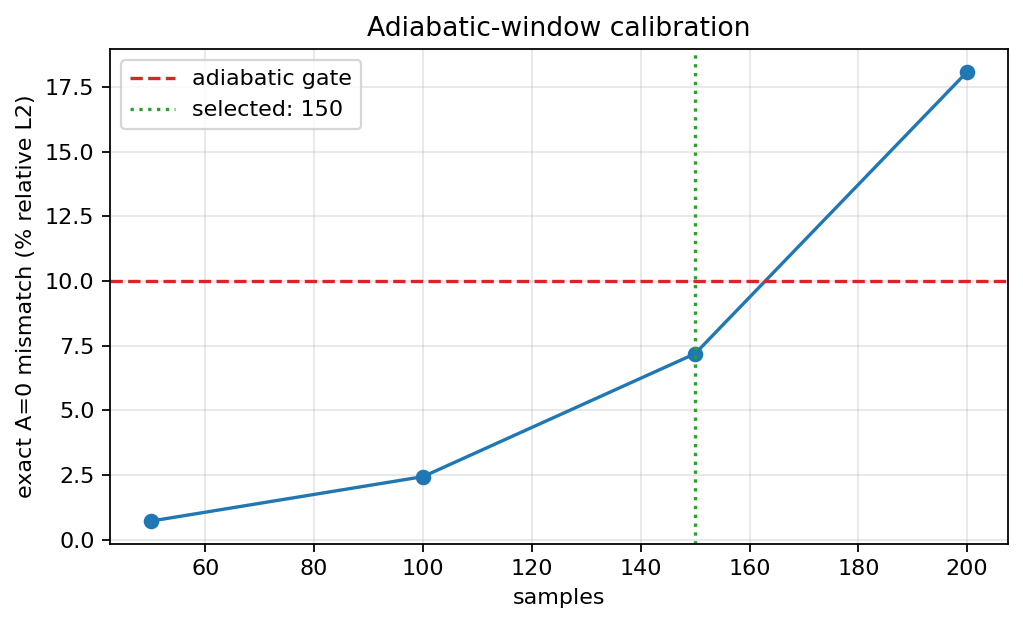

In [16]:
# Matched-forward control: train on waveform generated by this JAX forward model
hp_full = hp_gate[None, :]
hc_full = hc_gate[None, :]

print("MATCHED-FORWARD TARGET ENABLED")

# Calibrate the longest interval on which A=0 is actually adiabatic.
ADIABATIC_WINDOWS = (50, 100, 150, 200)
ADIABATIC_RELATIVE_L2_MAX = 10.0
ADIABATIC_MSE = {}

for window in ADIABATIC_WINDOWS:
    t_test = t_full[:window]
    trajectory_A0 = integrate_kerr(
        U0.astype(t_test.dtype), t_test, dissipation=0.0
    )
    hp_A0, hc_A0 = create_gravityWave(
        t_test, trajectory_A0, a_true,
        theta_obs=theta_observed[0].astype(t_test.dtype),
    )
    hp_target = hp_full[0, :window]
    hc_target = hc_full[0, :window]
    numerator = jnp.mean(
        (hp_A0 - hp_target)**2 + (hc_A0 - hc_target)**2
    )
    denominator = jnp.mean(hp_target**2 + hc_target**2) + 1e-12
    normalized_mse = float(jax.device_get(numerator / denominator))
    ADIABATIC_MSE[window] = normalized_mse
    print(
        f"window={window:4d}: normalized MSE={normalized_mse:.4e}, "
        f"relative L2={100.0 * math.sqrt(normalized_mse):.2f}%"
    )

acceptable_windows = [
    window for window in ADIABATIC_WINDOWS
    if 100.0 * math.sqrt(ADIABATIC_MSE[window])
    <= ADIABATIC_RELATIVE_L2_MAX
]
if not acceptable_windows:
    raise FloatingPointError(
        "No tested window satisfies the exact A=0 adiabatic gate."
    )

CONSERVATIVE_WINDOW = max(acceptable_windows)
ADIABATIC_FLOOR = ADIABATIC_MSE[CONSERVATIVE_WINDOW]
print("Selected conservative window:", CONSERVATIVE_WINDOW)

fig, ax = plt.subplots(figsize=(6.5, 4.0), dpi=160)
ax.plot(
    ADIABATIC_WINDOWS,
    [100.0 * math.sqrt(ADIABATIC_MSE[w]) for w in ADIABATIC_WINDOWS],
    "o-",
)
ax.axhline(
    ADIABATIC_RELATIVE_L2_MAX, color="tab:red", ls="--",
    label="adiabatic gate",
)
ax.axvline(
    CONSERVATIVE_WINDOW, color="tab:green", ls=":",
    label=f"selected: {CONSERVATIVE_WINDOW}",
)
ax.set(
    xlabel="samples", ylabel="exact A=0 mismatch (% relative L2)",
    title="Adiabatic-window calibration",
)
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Checkpoints

In [17]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    SAVE_DIR = Path("/content/drive/MyDrive")
except ImportError:
    SAVE_DIR = Path(".")

RUN_ID = "sonar_v56_A_oracle_control"
RESUME = False

CHECKPOINT_PATH = SAVE_DIR / f"{RUN_ID}_live.npz"
FINAL_PATH = SAVE_DIR / f"{RUN_ID}_final.npz"

def save_checkpoint(path, params, stage_idx, epoch, n, histories):
    flat, _ = ravel_pytree(params)
    np.savez(
        path,
        flat_params=np.asarray(jax.device_get(flat)),
        stage_idx=stage_idx,
        epoch=epoch,
        n=n,
        **{name: np.asarray(values) for name, values in histories.items()},
    )


def load_checkpoint(path, template):
    if not Path(path).exists():
        return None
    data = np.load(path)
    _, unravel = ravel_pytree(template)
    loaded = unravel(jnp.asarray(data["flat_params"]))
    names = (
        "total", "waveform", "ricci",
        "boundary", "mass_shell",
        "monitor_ic", "monitor_metric",
    )
    histories = {
        name: data[name].tolist() if name in data else []
        for name in names
    }
    return loaded, int(data["stage_idx"]), int(data["epoch"]), int(data["n"]), histories


def import_pytorch_checkpoint(path):
    '''Optional one-time import of the original .pt network weights.'''
    import torch
    payload = torch.load(path, map_location="cpu")
    state = payload.get("net_state", payload)
    return {
        "w1": jnp.asarray(state["fc1.weight"].detach().numpy()),
        "b1": jnp.asarray(state["fc1.bias"].detach().numpy()),
        "w2": jnp.asarray(state["fc2.weight"].detach().numpy()),
        "b2": jnp.asarray(state["fc2.bias"].detach().numpy()),
    }

# To continue from a trained PyTorch model, uncomment before training:
# params = import_pytorch_checkpoint("/content/drive/MyDrive/sonar_v16_final.pt")


Mounted at /content/drive


## LM monitoring

In [18]:
def metric_errors(params):
    metric_params = params["metric"]

    radii = jnp.asarray(
        [2, 3, 4, 5, 6, 12, 20],
        dtype=metric_params["w1"].dtype,
    )
    angles = jnp.asarray(
        [math.pi / 20, math.pi / 4, math.pi / 3, math.pi / 2],
        dtype=metric_params["w1"].dtype,
    )

    def errors_at_r(r):
        pred = jax.vmap(
            lambda th: metric_from_network(metric_params, r, th)
        )(angles)

        true = jax.vmap(
            lambda th: g_Kerr(r, th)
        )(angles)

        ij = jnp.asarray([
            [0, 0],
            [1, 1],
            [2, 2],
            [3, 3],
            [0, 3],
        ])

        return jax.vmap(
            lambda pair:
                100.0
                * jnp.linalg.norm(
                    pred[:, pair[0], pair[1]]
                    - true[:, pair[0], pair[1]]
                )
                / (
                    jnp.linalg.norm(
                        true[:, pair[0], pair[1]]
                    )
                    + 1e-12
                )
        )(ij)

    return jax.vmap(errors_at_r)(radii).T


metric_errors_jit = jax.jit(metric_errors)

histories = {name: [] for name in (
    "total", "waveform", "ricci",
    "boundary", "mass_shell",
    "monitor_ic", "monitor_metric",
)}

def record_monitor(current_params):
    u = np.asarray(
        jax.device_get(decode_ic(current_params["ic"], current_params["metric"])),
        dtype=float,
    )

    # Mean error for each metric component over r >= 3.
    metric_error = np.asarray(
        jax.device_get(metric_errors_jit(current_params)),
        dtype=float,
    )[:, 1:].mean(axis=1)

    histories["monitor_ic"].append([
        u[1],       # r
        u[2],       # theta
        -u[4],      # E
        u[7],       # Lz
    ])
    histories["monitor_metric"].append(metric_error)

n = 0

if RESUME:
    restored = load_checkpoint(CHECKPOINT_PATH, params)
    if restored is not None:
        params, _, _, n, histories = restored
        print("resumed:", n)

if not histories["monitor_ic"]:
    record_monitor(params)

## Oracle control, two-stage learning, and guarded joint polish

The oracle first tests the scalar-$A$ machinery on the exact conservative background. Stage 1 then learns the conservative metric and initial conditions from a short window; Stage 2 learns $A$ on the resulting background. The final joint step is deliberately short.


In [19]:
from scipy.optimize import least_squares, minimize_scalar

# The matched-forward control remains in float64 for the LM handoff.
params = tree_util.tree_map(lambda x: jnp.asarray(x, dtype=jnp.float64), params)
t_full = t_full.astype(jnp.float64)
trajectory_gate, (hp_gate, hc_gate) = exact_kerr_gate(t_full)
hp_full = hp_gate[None, :]
hc_full = hc_gate[None, :]
LOSS_WEIGHTS = LOSS_WEIGHTS.astype(jnp.float64)
LM_NONFINITE = {"residual": 0, "jacobian": 0}

CONSERVATIVE_MAX_NFEV = 100
CONSERVATIVE_MAX_OPTIMALITY = 1e-1
CONSERVATIVE_MAX_WAVEFORM_LOSS = max(2.0 * ADIABATIC_FLOOR, 1e-3)
A_BOUNDS = (-3.0, 0.0)
A_INTERIOR_FRACTION = 0.01
POLISH_MAX_NFEV = 15
R_MIN_GATE = 2.0
R_MAX_GATE = 25.0

integrate_network_jit = jax.jit(integrate_network)


# Oracle control: can the scalar search recover A when the conservative
# background is exactly correct? This must pass before any learning.
ORACLE_A_RELATIVE_ERROR_MAX_PCT = 1.0
oracle_A_search_history = []

def normalized_single_observer_waveform_loss(hp_pred, hc_pred):
    truth_power = lax.stop_gradient(
        jnp.mean(hp_full[0]**2 + hc_full[0]**2)
    )
    squared_error = jnp.mean(
        (hp_pred - hp_full[0])**2 + (hc_pred - hc_full[0])**2
    )
    return squared_error / (truth_power + 1e-12)

@jax.jit
def exact_background_A_loss(amplitude):
    trajectory = integrate_kerr(
        U0.astype(t_full.dtype), t_full, dissipation=amplitude
    )
    hp_pred, hc_pred = create_gravityWave(
        t_full, trajectory, a_true,
        theta_obs=theta_observed[0].astype(t_full.dtype),
    )
    return normalized_single_observer_waveform_loss(hp_pred, hc_pred)

def oracle_A_objective(amplitude):
    value = float(jax.device_get(exact_background_A_loss(
        jnp.asarray(amplitude, dtype=t_full.dtype)
    )))
    finite_value = value if np.isfinite(value) else 1e30
    oracle_A_search_history.append((float(amplitude), finite_value))
    return finite_value

oracle_stage_result = minimize_scalar(
    oracle_A_objective,
    bounds=A_BOUNDS,
    method="bounded",
    options={"xatol": 1e-6, "maxiter": 60},
)
oracle_A_fit = float(oracle_stage_result.x)
oracle_A_error_pct = 100.0 * abs(
    (oracle_A_fit - DISSIPATION_TRUE) / DISSIPATION_TRUE
)
oracle_margin = A_INTERIOR_FRACTION * (A_BOUNDS[1] - A_BOUNDS[0])
oracle_A_is_interior = bool(
    A_BOUNDS[0] + oracle_margin
    < oracle_A_fit
    < A_BOUNDS[1] - oracle_margin
)
oracle_accepted = bool(
    oracle_stage_result.success
    and np.isfinite(oracle_stage_result.fun)
    and oracle_A_is_interior
    and oracle_A_error_pct <= ORACLE_A_RELATIVE_ERROR_MAX_PCT
)

print("\nExact-background A oracle")
print("Search success:", oracle_stage_result.success)
print("Recovered / true A:", oracle_A_fit, DISSIPATION_TRUE)
print("A error (%):", oracle_A_error_pct)
print("Waveform loss:", oracle_stage_result.fun)
print("Oracle accepted:", oracle_accepted)

if not oracle_accepted:
    raise FloatingPointError(
        "Exact Kerr + exact IC failed to recover A; stop before LM."
    )


def with_physical_A(joint, amplitude):
    """Return a new joint pytree whose stored coordinate decodes to amplitude."""
    dtype = joint["metric"]["w1"].dtype
    return {
        **joint,
        "dissipation": jnp.asarray(
            encode_dissipation(amplitude), dtype=dtype
        ),
    }


def forward_gate(joint, t_array):
    """Reject finite-but-unbound, plunging, and escaping candidates."""
    u0 = decode_ic(joint["ic"], joint["metric"])
    trajectory = integrate_network_jit(
        joint["metric"], u0, joint["dissipation"], t_array
    )
    hp, hc = create_gravityWave(
        t_array,
        trajectory,
        a_true,
        theta_obs=theta_observed[0].astype(t_array.dtype),
    )
    u0, trajectory, hp, hc = jax.device_get((u0, trajectory, hp, hc))
    u0 = np.asarray(u0)
    trajectory = np.asarray(trajectory)
    hp = np.asarray(hp)
    hc = np.asarray(hc)
    finite = bool(
        np.isfinite(u0).all()
        and np.isfinite(trajectory).all()
        and np.isfinite(hp).all()
        and np.isfinite(hc).all()
    )
    E = float(-u0[4]) if np.isfinite(u0[4]) else float("nan")
    if finite:
        r_min = float(np.min(trajectory[:, 1]))
        r_max = float(np.max(trajectory[:, 1]))
    else:
        r_min = float("nan")
        r_max = float("nan")
    bound_energy = bool(np.isfinite(E) and E_LO <= E <= E_HI)
    radial_ok = bool(
        finite and R_MIN_GATE < r_min and r_max < R_MAX_GATE
    )
    return {
        "accepted": finite and bound_energy and radial_ok,
        "finite": finite,
        "E": E,
        "r_min": r_min,
        "r_max": r_max,
        "bound_energy": bound_energy,
        "radial_ok": radial_ok,
    }


def full_loss_value(joint):
    value = loss_only(
        joint, t_full, hp_full, hc_full, LOSS_WEIGHTS
    )[0]
    return float(jax.device_get(value))


def run_lm_stage(
    *,
    stage_name,
    stage_idx,
    window,
    params,
    weights,
    active_keys,
    max_nfev,
    validation_t,
    require_improvement=False,
    max_optimality=None,
    max_waveform_loss=None,
):
    """Optimize selected pytree blocks and accept only a stable endpoint."""
    t_window = t_full[:window]
    hp_window = hp_full[:, :window]
    hc_window = hc_full[:, :window]

    base_params = params
    active_template = {key: params[key] for key in active_keys}
    x0, unravel_active = ravel_pytree(active_template)
    x0 = jnp.asarray(x0, dtype=jnp.float64)

    def rebuild(x):
        return {**base_params, **unravel_active(x)}

    def residual_flat(x):
        return full_residual_vector(
            rebuild(x),
            t_window,
            hp_window,
            hc_window,
            weights,
        )

    residual_jit = jax.jit(residual_flat)
    jacobian_jit = jax.jit(jax.jacfwd(residual_flat))

    r0 = residual_jit(x0)
    J0 = jacobian_jit(x0)
    J0.block_until_ready()
    residual_finite = np.isfinite(np.asarray(r0)).all()
    jacobian_finite = np.isfinite(np.asarray(J0)).all()
    print(f"\n{stage_name}")
    print("Finite starting residual:", residual_finite)
    print("Finite starting Jacobian:", jacobian_finite)
    if not (residual_finite and jacobian_finite):
        raise FloatingPointError(
            f"{stage_name} rejected before optimization."
        )

    old_loss = loss_only(
        params, t_window, hp_window, hc_window, weights
    )[0]
    residual_loss = r0 @ r0
    print("Original scalar loss:", float(old_loss))
    print("Residual squared norm:", float(residual_loss))
    print("Jacobian shape:", J0.shape)
    print("Jacobian condition:", float(jnp.linalg.cond(J0)))

    if not np.isclose(
        float(old_loss), float(residual_loss), rtol=1e-7, atol=1e-12
    ):
        raise RuntimeError("Residual vector does not reproduce scalar loss.")

    component_names = (
        "waveform", "ricci", "boundary", "mass_shell"
    )
    component_sizes = (
        2 * hp_window.size,
        RICCI_POINTS.shape[0] * 16,
        3 * BC_THETA.size,
        1,
    )

    def record_lm_evaluation(residual):
        if residual.size != sum(component_sizes):
            raise RuntimeError("Unexpected LM residual-vector size.")
        offset = 0
        weighted_components = []
        for size in component_sizes:
            block = residual[offset:offset + size]
            weighted_components.append(float(block @ block))
            offset += size
        histories["total"].append(float(sum(weighted_components)))
        for name, value in zip(component_names, weighted_components):
            histories[name].append(value)

    def residual_numpy(x):
        value = residual_jit(jnp.asarray(x, dtype=jnp.float64))
        residual = np.asarray(jax.device_get(value), dtype=np.float64)
        if not np.isfinite(residual).all():
            LM_NONFINITE["residual"] += 1
            residual = np.nan_to_num(
                residual, nan=1e6, posinf=1e6, neginf=-1e6
            )
        record_lm_evaluation(residual)
        return residual

    def jacobian_numpy(x):
        value = jacobian_jit(jnp.asarray(x, dtype=jnp.float64))
        jacobian = np.asarray(jax.device_get(value), dtype=np.float64)
        if not np.isfinite(jacobian).all():
            LM_NONFINITE["jacobian"] += 1
            jacobian = np.nan_to_num(
                jacobian, nan=0.0, posinf=0.0, neginf=0.0
            )
        return jacobian

    result = least_squares(
        residual_numpy,
        np.asarray(x0, dtype=np.float64),
        jac=jacobian_numpy,
        method="lm",
        x_scale="jac",
        ftol=1e-13,
        xtol=1e-13,
        gtol=1e-10,
        max_nfev=max_nfev,
        verbose=2,
    )

    candidate_x = jnp.asarray(result.x, dtype=jnp.float64)
    candidate = rebuild(candidate_x)
    gate = forward_gate(candidate, validation_t)
    candidate_residual = np.asarray(
        jax.device_get(residual_jit(candidate_x)), dtype=np.float64
    )
    waveform_weight = float(np.asarray(weights)[0])
    if waveform_weight <= 0.0:
        raise ValueError("Waveform weight must be positive for the fit gate.")
    waveform_block = candidate_residual[:component_sizes[0]]
    candidate_waveform_loss = float(
        (waveform_block @ waveform_block) / waveform_weight
    )
    optimality_valid = bool(
        max_optimality is None or result.optimality <= max_optimality
    )
    waveform_fit_valid = bool(
        max_waveform_loss is None
        or candidate_waveform_loss <= max_waveform_loss
    )
    quality_ok = optimality_valid and waveform_fit_valid
    candidate_loss = full_loss_value(candidate)
    baseline_loss = full_loss_value(params)
    loss_valid = np.isfinite(candidate_loss)
    improved = loss_valid and candidate_loss <= baseline_loss
    candidate_A = float(decode_dissipation(candidate["dissipation"]))
    amplitude_valid = A_BOUNDS[0] <= candidate_A <= A_BOUNDS[1]
    accepted = (
        gate["accepted"]
        and loss_valid
        and amplitude_valid
        and quality_ok
        and (improved or not require_improvement)
    )

    print("LM equivalent loss:", 2.0 * result.cost)
    print("LM evaluations:", result.nfev)
    print("Validation forward finite:", gate["finite"])
    print(
        f"E={gate['E']:.6f}, "
        f"r-range=[{gate['r_min']:.3f}, {gate['r_max']:.3f}], "
        f"orbit gate={gate['accepted']}"
    )
    print("Stage waveform loss / limit:", candidate_waveform_loss, max_waveform_loss)
    print("Optimality / limit:", result.optimality, max_optimality)
    print("Fit-quality gate:", quality_ok)
    print("Physical A / within bounds:", candidate_A, amplitude_valid)
    print("Full loss finite:", loss_valid)
    print("Full loss before/after:", baseline_loss, candidate_loss)
    print("Stage accepted:", accepted)

    if not accepted:
        return params, result, False

    record_monitor(candidate)
    save_checkpoint(
        SAVE_DIR / f"{RUN_ID}_stage{stage_idx}_{stage_name}.npz",
        candidate,
        stage_idx,
        result.nfev,
        len(histories["total"]),
        histories,
    )
    return candidate, result, True


lm_start = time.time()

# Stage 1: conservative metric + IC only. Dissipation is exactly zero.
params_stage0 = with_physical_A(params, 0.0)
params_stage1, conservative_result, conservative_accepted = run_lm_stage(
    stage_name="conservative",
    stage_idx=1,
    window=CONSERVATIVE_WINDOW,
    params=params_stage0,
    weights=LOSS_WEIGHTS,
    active_keys=("metric", "ic"),
    max_nfev=CONSERVATIVE_MAX_NFEV,
    validation_t=t_full,
    max_optimality=CONSERVATIVE_MAX_OPTIMALITY,
    max_waveform_loss=CONSERVATIVE_MAX_WAVEFORM_LOSS,
)
if not conservative_accepted:
    raise FloatingPointError(
        "Conservative stage rejected by the convergence, waveform, or orbit gate."
    )


# Stage 2: metric and IC are frozen; search only the physical amplitude A.
A_search_history = []
u0_stage1 = decode_ic(params_stage1["ic"], params_stage1["metric"])

def A_waveform_loss(raw_coordinate):
    return waveform_loss(
        params_stage1["metric"],
        u0_stage1,
        raw_coordinate,
        t_full,
        hp_full,
        hc_full,
    )[0]

A_waveform_loss_jit = jax.jit(A_waveform_loss)

def bounded_A_objective(amplitude):
    raw = jnp.asarray(
        encode_dissipation(amplitude), dtype=t_full.dtype
    )
    value = float(jax.device_get(A_waveform_loss_jit(raw)))
    finite_value = value if np.isfinite(value) else 1e30
    A_search_history.append((float(amplitude), finite_value))
    return finite_value

stage2_result = minimize_scalar(
    bounded_A_objective,
    bounds=A_BOUNDS,
    method="bounded",
    options={"xatol": 1e-6, "maxiter": 60},
)
A_fit = float(stage2_result.x)
params_stage2_candidate = with_physical_A(params_stage1, A_fit)
stage2_gate = forward_gate(params_stage2_candidate, t_full)
stage2_loss_valid = np.isfinite(stage2_result.fun) and stage2_result.fun < 1e29
A_margin = A_INTERIOR_FRACTION * (A_BOUNDS[1] - A_BOUNDS[0])
A_is_interior = bool(
    A_BOUNDS[0] + A_margin < A_fit < A_BOUNDS[1] - A_margin
)

print("\nDissipative stage")
print("Bounded search success:", stage2_result.success)
print("A bounds:", A_BOUNDS)
print("Learned A:", A_fit)
print("Full forward finite:", stage2_gate["finite"])
print("Full orbit gate:", stage2_gate)
print("Interior A optimum:", A_is_interior)
print("Waveform loss:", stage2_result.fun)

stage2_accepted = bool(
    stage2_result.success
    and stage2_gate["accepted"]
    and stage2_loss_valid
    and A_is_interior
)
print("Stage accepted:", stage2_accepted)

# The decisive visual: identical A searches on exact and learned backgrounds.
oracle_history = np.asarray(oracle_A_search_history, dtype=float)
learned_history = np.asarray(A_search_history, dtype=float)

def plot_A_profile(ax, history, fitted_A, title):
    order = np.argsort(history[:, 0])
    ax.semilogy(
        history[order, 0],
        np.maximum(history[order, 1], 1e-30),
        "o-", ms=4, label="bounded search",
    )
    ax.axvline(
        DISSIPATION_TRUE, color="tab:green", ls=":", label="true A"
    )
    ax.axvline(
        fitted_A, color="tab:orange", ls="--",
        label=f"fit A={fitted_A:.4f}",
    )
    ax.set(xlabel="A", ylabel="full-waveform loss", title=title)
    ax.set_xlim(A_BOUNDS)
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), dpi=160)
plot_A_profile(
    axes[0], oracle_history, oracle_A_fit,
    "Exact Kerr + exact IC",
)
plot_A_profile(
    axes[1], learned_history, A_fit,
    "Learned metric + learned IC",
)
fig.tight_layout()
plt.show()

if not stage2_accepted:
    raise FloatingPointError("Dissipative stage rejected; inspect the A profile.")

params_stage2 = params_stage2_candidate
save_checkpoint(
    SAVE_DIR / f"{RUN_ID}_stage2_dissipation.npz",
    params_stage2,
    2,
    stage2_result.nfev,
    len(histories["total"]),
    histories,
)


# Joint polish: all parameters, one full window, only 15 evaluations.
try:
    params_polished, polish_result, polish_accepted = run_lm_stage(
        stage_name="joint_polish",
        stage_idx=3,
        window=len(t_full),
        params=params_stage2,
        weights=LOSS_WEIGHTS,
        active_keys=("metric", "ic", "dissipation"),
        max_nfev=POLISH_MAX_NFEV,
        validation_t=t_full,
        require_improvement=True,
    )
except FloatingPointError as error:
    print("Joint polish rejected:", error)
    params_polished = params_stage2
    polish_result = None
    polish_accepted = False

params = params_polished if polish_accepted else params_stage2
lm_result = polish_result if polish_accepted else None
FINAL_NFEV = polish_result.nfev if polish_accepted else stage2_result.nfev

print("\nFinal accepted source:", "joint polish" if polish_accepted else "stage 2")
print("Final physical A:", float(decode_dissipation(params["dissipation"])))
print("Total minutes:", (time.time() - lm_start) / 60.0)
print("Rejected non-finite LM residual trials:", LM_NONFINITE["residual"])
print("Sanitized non-finite LM Jacobians:", LM_NONFINITE["jacobian"])



Exact-background A oracle
Search success: True
Recovered / true A: -1.014843341552752 -1.68
A error (%): 39.59265824090761
Waveform loss: 1.3711032609220162
Oracle accepted: False


FloatingPointError: Exact Kerr + exact IC failed to recover A; stop before LM.

  0/141: A = -1.7800
 20/141: A = -1.7514
 40/141: A = -1.7229
 60/141: A = -1.6943
 80/141: A = -1.6657
100/141: A = -1.6371
120/141: A = -1.6086
140/141: A = -1.5800


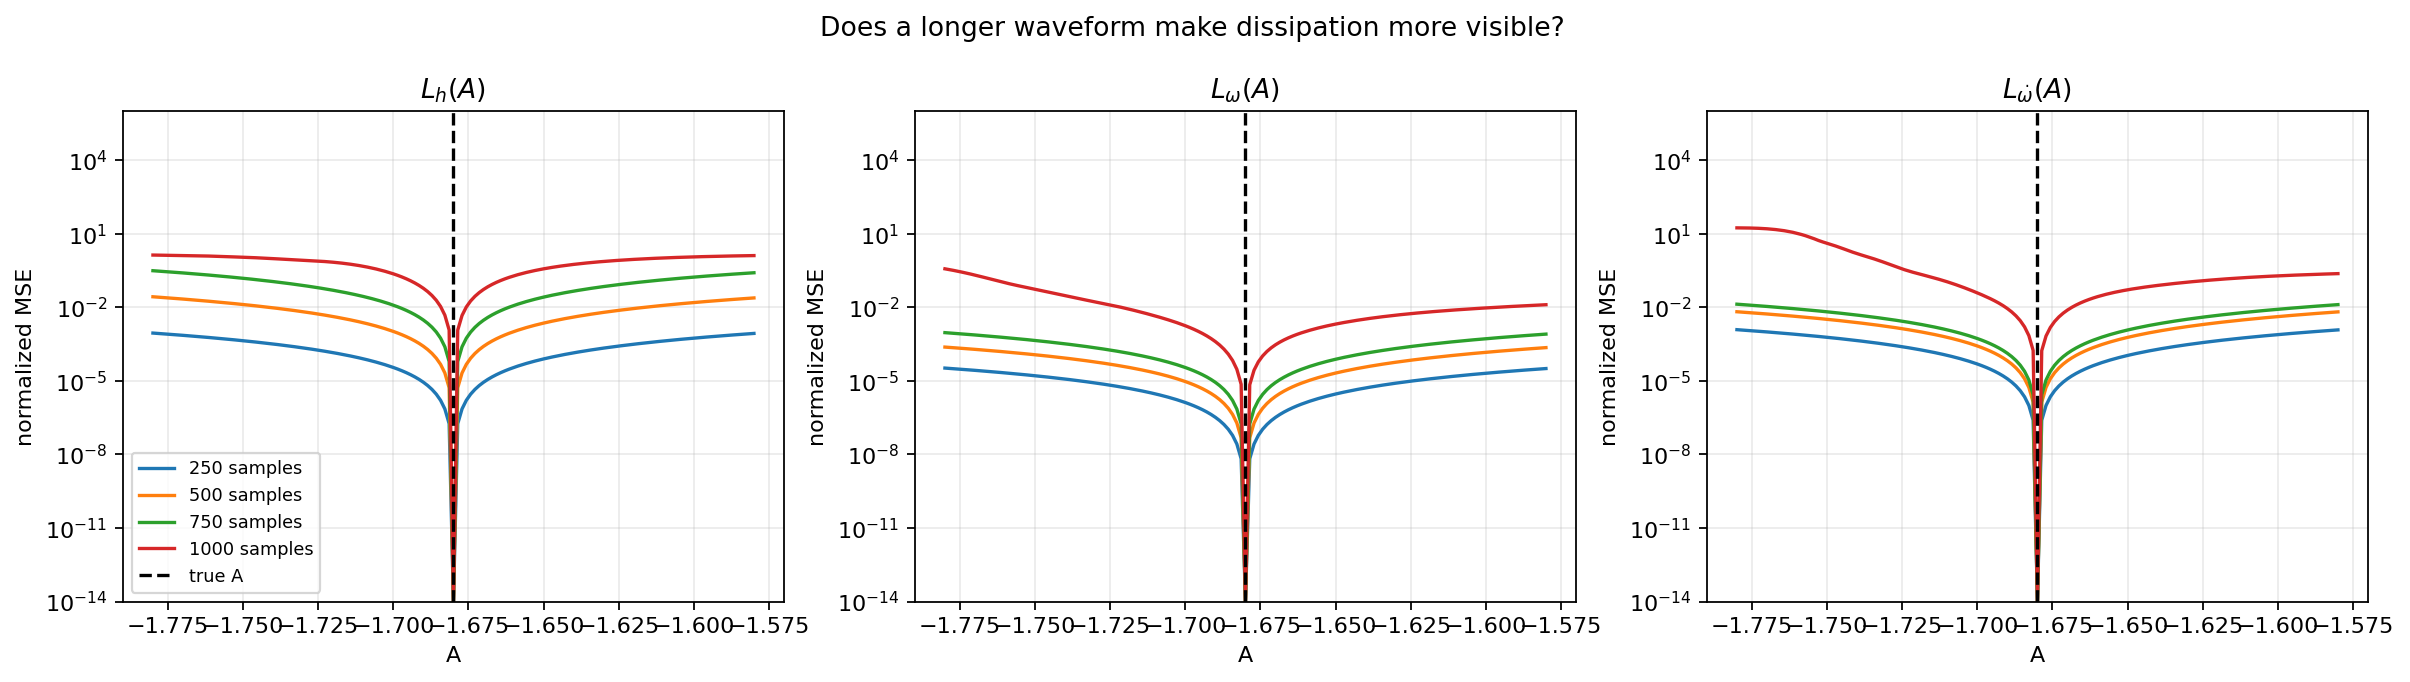


Local curvature L''(A_true): larger = more sensitive

waveform
   250 samples: 1.767862e-01
   500 samples: 5.182791e+00
   750 samples: 6.064146e+01
  1000 samples: 1.167539e+03

frequency
   250 samples: 6.555907e-03
   500 samples: 4.700425e-02
   750 samples: 1.741094e-01
  1000 samples: 7.009684e+00

chirp
   250 samples: 2.450208e-01
   500 samples: 1.335072e+00
   750 samples: 2.681436e+00
  1000 samples: 1.706547e+02


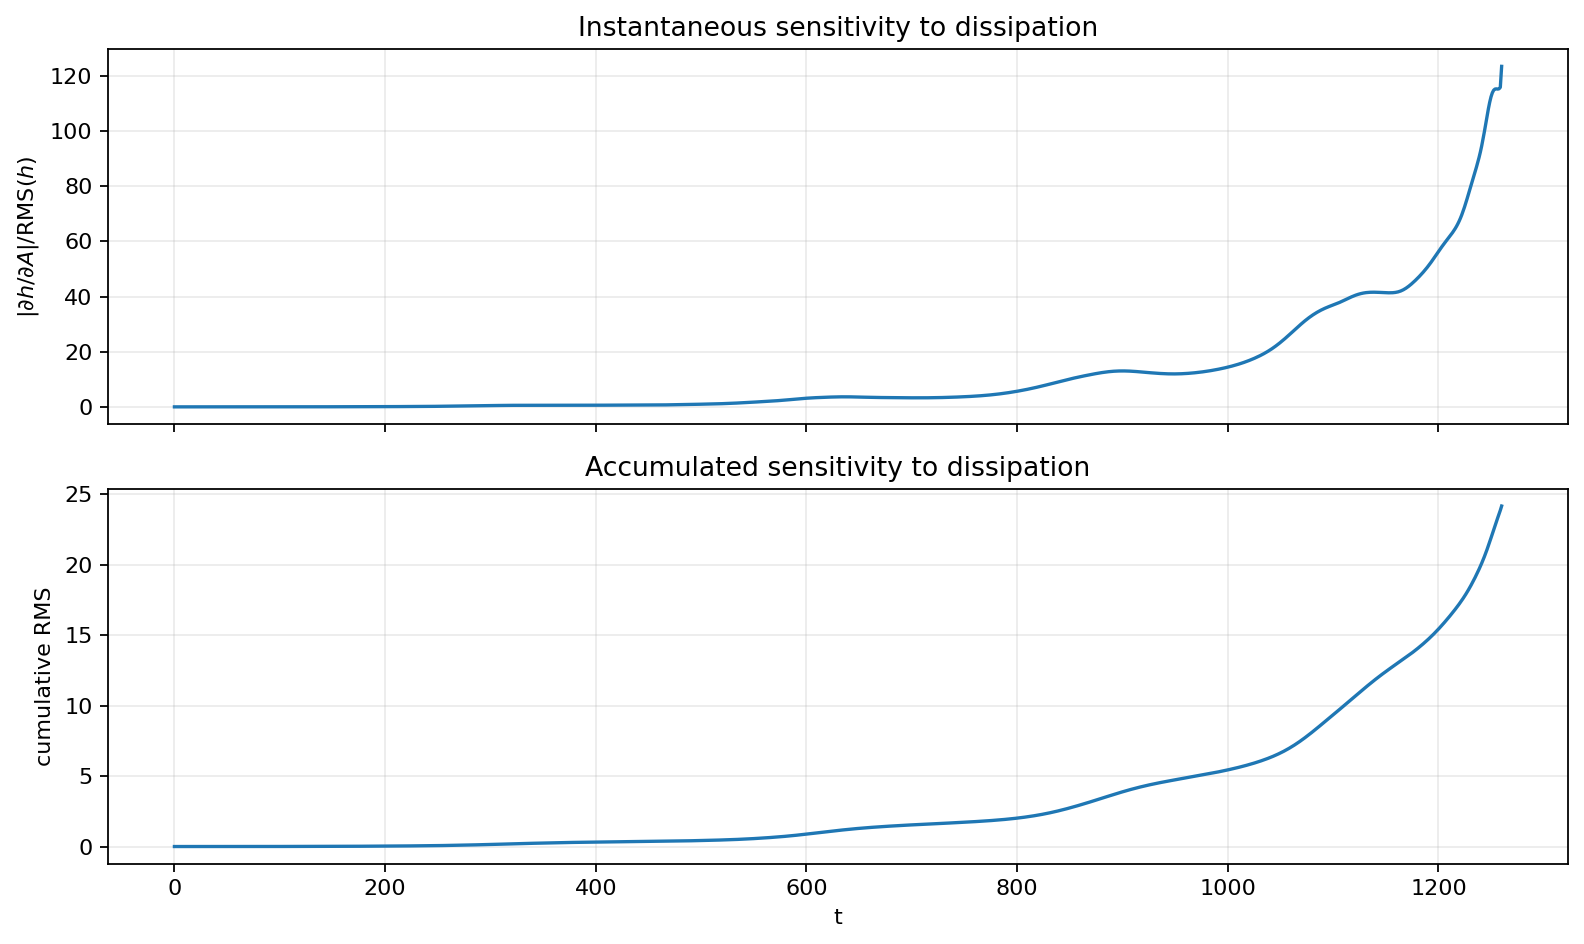

In [21]:
# ============================================================
# SIMPLE A-SENSITIVITY EXPERIMENT
# Tests L_h(A), L_omega(A), L_domega(A), and |dh/dA|
# ============================================================

from scipy.signal import savgol_filter

# Local zoom around the true A.
A_GRID = np.linspace(
    DISSIPATION_TRUE - 0.1,
    DISSIPATION_TRUE + 0.1,
    141,
)

# Four increasingly long waveform windows.
N_WINDOWS = (np.arange(1, 5) * len(t_full) // 4).astype(int)

t_diag = t_full.astype(jnp.float64)
u_diag = U0.astype(jnp.float64)
t_np = np.asarray(t_diag)


# ----- Exact Kerr waveform for any physical A -----

@jax.jit
def waveform_at_A(A):
    trajectory = integrate_kerr(
        u_diag,
        t_diag,
        dissipation=A,
    )

    hp, hc = create_gravityWave(
        t_diag,
        trajectory,
        a_true,
        theta_obs=theta_observed[0].astype(t_diag.dtype),
    )

    return hp + 1j * hc


# ----- Phase, frequency, and chirp -----

def frequency_and_chirp(h, t):
    phase = np.unwrap(np.angle(h))
    dt = float(t[1] - t[0])

    # Mild smoothing prevents two numerical derivatives from amplifying noise.
    omega = savgol_filter(
        phase, 31, 3,
        deriv=1, delta=dt,
        mode="interp",
    )

    domega = savgol_filter(
        phase, 31, 3,
        deriv=2, delta=dt,
        mode="interp",
    )

    return omega, domega


def normalized_mse(predicted, truth):
    return (
        np.mean(np.abs(predicted - truth)**2)
        / (np.mean(np.abs(truth)**2) + 1e-30)
    )


# ----- Exact target -----

h_true = np.asarray(jax.device_get(
    waveform_at_A(
        jnp.asarray(DISSIPATION_TRUE, dtype=t_diag.dtype)
    )
))

truth_data = {}

for n in N_WINDOWS:
    h_n = h_true[:n]
    t_n = t_np[:n]
    omega_n, domega_n = frequency_and_chirp(h_n, t_n)

    # Avoid endpoint derivatives and poorly defined phase near amplitude zeros.
    mask = np.abs(h_n) > 0.05 * np.max(np.abs(h_n))
    mask[:15] = False
    mask[-15:] = False

    truth_data[n] = {
        "h": h_n,
        "omega": omega_n,
        "domega": domega_n,
        "mask": mask,
    }


# ----- Scan A only once; reuse each waveform at all four durations -----

losses = {
    "waveform": np.full((len(N_WINDOWS), len(A_GRID)), np.nan),
    "frequency": np.full((len(N_WINDOWS), len(A_GRID)), np.nan),
    "chirp": np.full((len(N_WINDOWS), len(A_GRID)), np.nan),
}

for j, A in enumerate(A_GRID):
    h_pred = np.asarray(jax.device_get(
        waveform_at_A(jnp.asarray(A, dtype=t_diag.dtype))
    ))

    if np.isfinite(h_pred).all():
        for i, n in enumerate(N_WINDOWS):
            h_n = h_pred[:n]
            t_n = t_np[:n]

            omega_n, domega_n = frequency_and_chirp(h_n, t_n)
            true = truth_data[n]
            mask = true["mask"]

            losses["waveform"][i, j] = normalized_mse(
                h_n,
                true["h"],
            )

            losses["frequency"][i, j] = normalized_mse(
                omega_n[mask],
                true["omega"][mask],
            )

            losses["chirp"][i, j] = normalized_mse(
                domega_n[mask],
                true["domega"][mask],
            )

    if j % 20 == 0:
        print(f"{j:3d}/{len(A_GRID)}: A = {A:.4f}")


# ----- Plot the three loss landscapes -----

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3), dpi=160)

plot_info = [
    ("waveform", r"$L_h(A)$"),
    ("frequency", r"$L_\omega(A)$"),
    ("chirp", r"$L_{\dot{\omega}}(A)$"),
]

for ax, (name, title) in zip(axes, plot_info):
    for i, n in enumerate(N_WINDOWS):
        y = np.clip(losses[name][i], 1e-14, 1e6)
        ax.semilogy(A_GRID, y, label=f"{n} samples")

    ax.axvline(
        DISSIPATION_TRUE,
        color="black",
        linestyle="--",
        label="true A",
    )

    ax.set(
        xlabel="A",
        ylabel="normalized MSE",
        title=title,
        ylim=(1e-14, 1e6),
    )
    ax.grid(alpha=0.25)

axes[0].legend(fontsize=8)
fig.suptitle("Does a longer waveform make dissipation more visible?")
fig.tight_layout()
plt.show()


# ----- Numerical curvature: larger means more locally sensitive -----

center = len(A_GRID) // 2
dA_grid = A_GRID[1] - A_GRID[0]

print("\nLocal curvature L''(A_true): larger = more sensitive")

for name in losses:
    print(f"\n{name}")
    for i, n in enumerate(N_WINDOWS):
        L = losses[name][i]
        curvature = (
            L[center + 1]
            - 2.0 * L[center]
            + L[center - 1]
        ) / dA_grid**2

        print(f"  {n:4d} samples: {curvature:.6e}")


# ----- Direct waveform sensitivity |dh/dA| -----

DELTA_A = 1e-3

h_plus = np.asarray(jax.device_get(
    waveform_at_A(
        jnp.asarray(DISSIPATION_TRUE + DELTA_A, dtype=t_diag.dtype)
    )
))

h_minus = np.asarray(jax.device_get(
    waveform_at_A(
        jnp.asarray(DISSIPATION_TRUE - DELTA_A, dtype=t_diag.dtype)
    )
))

dh_dA = (h_plus - h_minus) / (2.0 * DELTA_A)

# Normalize by the RMS target waveform amplitude.
h_rms = np.sqrt(np.mean(np.abs(h_true)**2))
instantaneous_sensitivity = np.abs(dh_dA) / (h_rms + 1e-30)

cumulative_sensitivity = np.sqrt(
    np.cumsum(instantaneous_sensitivity**2)
    / np.arange(1, len(t_np) + 1)
)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), dpi=160, sharex=True)

axes[0].plot(t_np, instantaneous_sensitivity)
axes[0].set_ylabel(r"$|\partial h/\partial A|/\mathrm{RMS}(h)$")
axes[0].set_title("Instantaneous sensitivity to dissipation")
axes[0].grid(alpha=0.25)

axes[1].plot(t_np, cumulative_sensitivity)
axes[1].set(
    xlabel="t",
    ylabel="cumulative RMS",
    title="Accumulated sensitivity to dissipation",
)
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

In [ ]:
# Brute-force plot of waveform loss versus physical A.
A_grid = np.linspace(-2.0, -1.5, 1000)
L_grid = []

for i, A in enumerate(A_grid):
    loss_A = exact_background_A_loss(
        jnp.asarray(A, dtype=t_full.dtype)
    )
    loss_A = float(jax.device_get(loss_A))

    L_grid.append(loss_A if np.isfinite(loss_A) else np.nan)

    if i % 20 == 0:
        print(f"{i:3d}/{len(A_grid)}: A={A:.3f}, L={loss_A:.4e}")

L_grid = np.asarray(L_grid)

# Evaluate the injected value explicitly.
L_true = float(jax.device_get(
    exact_background_A_loss(
        jnp.asarray(DISSIPATION_TRUE, dtype=t_full.dtype)
    )
))

finite_indices = np.flatnonzero(np.isfinite(L_grid))
best_index = finite_indices[
    np.argmin(L_grid[finite_indices])
]

print("\nBest grid point:")
print("A =", A_grid[best_index])
print("L =", L_grid[best_index])

print("\nInjected value:")
print("A_true =", DISSIPATION_TRUE)
print("L(A_true) =", L_true)

print("Non-finite grid points:", np.sum(~np.isfinite(L_grid)))

plt.figure(figsize=(8, 5), dpi=160)

finite = np.isfinite(L_grid)
plt.semilogy(
    A_grid[finite],
    np.maximum(L_grid[finite], 1e-16),
    "o-",
    markersize=3,
)

plt.axvline(
    DISSIPATION_TRUE,
    color="tab:green",
    linestyle="--",
    label=f"True A = {DISSIPATION_TRUE}",
)

plt.scatter(
    [DISSIPATION_TRUE],
    [max(L_true, 1e-16)],
    marker="*",
    s=150,
    color="tab:red",
    label=f"L(A_true) = {L_true:.2e}",
    zorder=5,
)

plt.xlabel("A")
plt.ylabel("Normalized full-waveform loss")
plt.title("Exact Kerr + exact IC: L(A)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:

plt.figure(figsize=(8, 5), dpi=160)

finite = np.isfinite(L_grid)
plt.semilogy(
    A_grid[finite][1:],
    np.maximum(L_grid[finite][1:], 1e-16),
    "o-",
    markersize=3,
)

plt.axvline(
    DISSIPATION_TRUE,
    color="tab:green",
    linestyle="--",
    label=f"True A = {DISSIPATION_TRUE}",
)

plt.scatter(
    [DISSIPATION_TRUE],
    [max(L_true, 1e-16)],
    marker="*",
    s=150,
    color="tab:red",
    label=f"L(A_true) = {L_true:.2e}",
    zorder=5,
)

plt.xlabel("A")
plt.ylabel("Normalized full-waveform loss")
plt.title("Exact Kerr + exact IC: L(A)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
finite = np.isfinite(L_grid)

# Cap only the displayed values—not the scientific data.
L_plot = np.where(
    finite,
    np.clip(L_grid, 1e-12, 10.0),
    np.nan,
)

plt.figure(figsize=(8, 5), dpi=160)

plt.semilogy(
    A_grid,
    L_plot,
    "-",
    linewidth=1.5,
)

plt.axvline(
    DISSIPATION_TRUE,
    color="tab:green",
    linestyle="--",
    label=f"True A = {DISSIPATION_TRUE}",
)

plt.scatter(
    [DISSIPATION_TRUE],
    [np.clip(L_true, 1e-12, 10.0)],
    marker="*",
    s=150,
    color="tab:red",
    label="Exact injected value",
    zorder=5,
)

plt.ylim(1e-12, 10.0)
plt.xlabel("A")
plt.ylabel("Normalized full-waveform loss")
plt.title("Exact Kerr + exact IC: L(A)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Final diagnostics and save

In [ ]:
(final_loss, (final_components, final_roots, final_shell, u0_fit)) = loss_only(
    params, t_full, hp_full, hc_full, LOSS_WEIGHTS
)
final_loss.block_until_ready()
print("final loss:", float(final_loss))
print("raw [waveform, Ricci, boundary]:", np.asarray(final_components))
print("mean horizon proxy:", float(jnp.mean(final_roots)))

errors = np.asarray(metric_errors_jit(params))
labels = ["g_tt", "g_rr", "g_thth", "g_phph", "g_tph"]
radii = [2, 3, 4, 5, 6, 12, 20]
print("\nMetric relative L2 error across theta (%)")
print("component", *[f"r={r}" for r in radii])
for label, row in zip(labels, errors):
    print(label, *[f"{x:.3f}" for x in row])

trajectory = jax.jit(integrate_network)(
    params["metric"], u0_fit,
    params["dissipation"], t_full
)

hp_pred, hc_pred = jax.vmap(
    lambda theta: create_gravityWave(t_full, trajectory, a_true, theta_obs=theta)
)(theta_observed.astype(t_full.dtype))

print("Recovered u0:", np.asarray(u0_fit))
print("True u0:", np.asarray(U0))
print("Mass shell:", float(final_shell))

# Dissipation diagnostics
diss_learned_raw = float(params["dissipation"])
diss_learned_dimless = float(decode_dissipation(params["dissipation"]))
diss_learned_at_ref = (
    DISSIPATION_SCALE * diss_learned_dimless
    * DISSIPATION_R_REF ** (-DISSIPATION_EXPONENT)
)
diss_true_at_ref = (
    DISSIPATION_SCALE * DISSIPATION_TRUE
    * DISSIPATION_R_REF ** (-DISSIPATION_EXPONENT)
)

diss_error_pct = 100.0 * abs(
    (diss_learned_at_ref - diss_true_at_ref) / diss_true_at_ref
)

print("\nDissipation diagnostics")
print(r"Law                     : dot(p_phi) = A r^(-7/2)")
print(f"Reference radius        : {DISSIPATION_R_REF:.6f}")
print(f"Learned raw parameter    : {diss_learned_raw:.8f}")
print(f"Learned dimensionless d : {diss_learned_dimless:.8f}")
print(f"Learned flux at r_ref   : {diss_learned_at_ref:.8e}")
print(f"True flux at r_ref      : {diss_true_at_ref:.8e}")
print(f"Dissipation error       : {diss_error_pct:.6f}%")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(np.asarray(t_full), np.asarray(hp_full[0]), label="True")
axes[0].plot(np.asarray(t_full), np.asarray(hp_pred[0]), "--", label="JAX Sonar")
axes[0].set_ylabel(r"$h_+$")
axes[0].legend()
axes[1].plot(np.asarray(t_full), np.asarray(hc_full[0]), label="True")
axes[1].plot(np.asarray(t_full), np.asarray(hc_pred[0]), "--", label="JAX Sonar")
axes[1].set_ylabel(r"$h_\times$")
axes[1].set_xlabel("t")
axes[1].legend()
plt.tight_layout()

save_checkpoint(
    FINAL_PATH, params, len(t_full), FINAL_NFEV,
    len(histories["total"]), histories,
)
print("saved:", FINAL_PATH)

In [ ]:
ic = np.asarray(histories["monitor_ic"])
metric = np.asarray(histories["monitor_metric"])
steps = np.arange(len(ic))

ic_true = np.asarray([
    U0[1],
    U0[2],
    -U0[4],
    U0[7],
], dtype=float)

ic_error = 100 * np.abs((ic - ic_true) / ic_true)
ic_error = np.maximum(ic_error, 1e-12)

metric_labels = [
    r"$g_{tt}$", r"$g_{rr}$", r"$g_{\theta\theta}$",
    r"$g_{\phi\phi}$", r"$g_{t\phi}$",
]

fig, ax = plt.subplots(2, 2, figsize=(12, 9), dpi = 300)

# r-theta path
ax[0, 0].plot(ic[:, 0], ic[:, 1], ".-", alpha=0.6)
ax[0, 0].plot(ic[0, 0], ic[0, 1], "ks", label="Start")
ax[0, 0].plot(ic_true[0], ic_true[1], "r*", ms=14, label="Truth")
ax[0, 0].set(xlabel="r", ylabel=r"$\theta$", title="IC path: r, theta")
ax[0, 0].legend()

# E-Lz path
ax[0, 1].plot(ic[:, 2], ic[:, 3], ".-", alpha=0.6)
ax[0, 1].plot(ic[0, 2], ic[0, 3], "ks", label="Start")
ax[0, 1].plot(ic_true[2], ic_true[3], "r*", ms=14, label="Truth")
ax[0, 1].set(xlabel="E", ylabel=r"$L_z$", title="IC path: E, Lz")
ax[0, 1].legend()

# IC errors
for i, label in enumerate(["r", r"$\theta$", "E", r"$L_z$"]):
    ax[1, 0].plot(steps, ic_error[:, i], label=label)

ax[1, 0].set_yscale("log")
ax[1, 0].set(
    xlabel="Recorded optimizer step",
    ylabel="Absolute relative error (%)",
    title="IC errors",
)
ax[1, 0].legend()

# Metric errors
for i, label in enumerate(metric_labels):
    ax[1, 1].plot(steps, metric[:, i], label=label)

ax[1, 1].set_yscale("log")
ax[1, 1].set(
    xlabel="Recorded optimizer step",
    ylabel="Mean relative error (%)",
    title="Metric errors, r ≥ 3",
)
ax[1, 1].legend()

plt.tight_layout()

In [ ]:
def rel_L2(hp, hc):
    true = hp_full[0] + 1j * hc_full[0]
    pred = hp + 1j * hc
    return 100 * jnp.linalg.norm(pred - true) / jnp.linalg.norm(true)

def wave(traj):
    return create_gravityWave(
        t_full, traj, a_true,
        theta_obs=theta_observed[0].astype(t_full.dtype),
    )

u_true = U0.astype(t_full.dtype)
u_fit  = u0_fit.astype(t_full.dtype)

cases = {
    "Kerr metric + true IC":
        wave(jax.jit(integrate_kerr)(u_true, t_full)),

    "Kerr metric + learned IC":
        wave(jax.jit(integrate_kerr)(u_fit, t_full)),

    "Learned metric + true IC":
        wave(jax.jit(integrate_network)(params["metric"], u_true, params["dissipation"], t_full)),

    "Learned metric + learned IC":
        wave(jax.jit(integrate_network)(params["metric"], u_fit, params["dissipation"], t_full)),
}

for name, (hp, hc) in cases.items():
    print(f"{name:30s}: {float(rel_L2(hp, hc)):.6f}%")

# JAX diagnostics

These cells inspect optimizer geometry, local metric–IC distinguishability, spectra, horizon structure, and off-grid metric behavior.


In [ ]:
LAM_TRUE = DISSIPATION_TRUE
DIR = jnp.asarray([0, 0, 0, 0, 0, 0, 0, 1.])

def H_al(mp, s, α, λ):
  def ham(z):
    g = ((1-α)*Kerr(z[:4], a_true)
          + α*metric_from_network(mp, z[1], z[2]))
    return 0.5 * z[4:] @ jnp.linalg.inv(g) @ z[4:]
  gH = jax.grad(ham)(s)
  force = radial_angular_momentum_flux(s, λ) * DIR.astype(s.dtype)
  return ((SYMPLECTIC @ gH + force) / gH[4]).at[0].set(1.0)

def LW(α, λ):
  mp = params["metric"]
  traj = integrate(lambda t, s: H_al(mp, s, α, λ), U0, t_full)
  hp, hc = create_gravityWave(t_full,
                              traj,
                              a_true,
                              theta_obs=theta_observed[0])
  tr = hp_full[0] + 1j*hc_full[0]
  return jnp.linalg.norm((hp+1j*hc) - tr) / jnp.linalg.norm(tr)

A = jnp.linspace(0.0, 1.4, 21)
L = jnp.linspace(0.5, 1.5, 21) * LAM_TRUE
Z = jax.vmap(jax.vmap(LW, (None, 0)), (0, None))(A, L)
plt.contourf(L/LAM_TRUE, A, jnp.log10(Z), 30); plt.colorbar()
plt.xlabel("λ / λ_true")
plt.ylabel("α")
plt.axhline(1)
plt.axvline(1)

In [ ]:
def report_weighted_gradient_geometry(joint):
    """Gradients of every weighted scalar loss term with respect to all parameters."""
    x, unravel = ravel_pytree(joint)
    weights = LOSS_WEIGHTS.astype(x.dtype)

    def weighted_terms(x_flat):
        trial = unravel(x_flat)
        _, (components, _, shell, _) = loss(
            trial, t_full, hp_full, hc_full, weights
        )
        return jnp.concatenate((
            weights * components,
            jnp.asarray([P_MASS_SHELL * shell], dtype=x.dtype),
        ))

    values = jax.jit(weighted_terms)(x)
    gradients = jax.jit(jax.jacrev(weighted_terms))(x)
    values, gradients = jax.device_get((values, gradients))
    values = np.asarray(values)
    gradients = np.asarray(gradients)

    labels = ["waveform", "Ricci", "boundary", "mass shell"]
    norms = np.linalg.norm(gradients, axis=1)
    cosine = gradients @ gradients.T / (
        norms[:, None] * norms[None, :] + 1e-300
    )

    print("Weighted loss and gradient norms")
    for label, value, norm in zip(labels, values, norms):
        print(f"{label:12s} loss={value:.6e}  |grad|={norm:.6e}")

    print("\nPairwise gradient cosines")
    print(" " * 13 + " ".join(f"{x[:5]:>8s}" for x in labels))
    for label, row in zip(labels, cosine):
        print(f"{label:12s} " + " ".join(f"{x:+8.4f}" for x in row))

    return {"labels": labels, "values": values, "gradients": gradients,
            "norms": norms, "cosine": cosine}


def report_lm_jacobian_geometry(lm_result, n_time=None, rank_rtol=1e-10):
    """Use the final LM Jacobian; no second expensive jacfwd call."""
    J = np.asarray(lm_result.jac, dtype=float)
    if n_time is None:
        n_time = hp_full.shape[1]

    n_wave = 2 * hp_full.shape[0] * n_time
    J_wave = J[:n_wave]

    # Derive parameter-column ownership from pytree
    def columns_for(key):
        marker = tree_util.tree_map(jnp.zeros_like, params)
        marker[key] = tree_util.tree_map(jnp.ones_like, params[key])
        flat = np.asarray(jax.device_get(ravel_pytree(marker)[0]))
        return np.flatnonzero(flat != 0)

    metric_cols = columns_for("metric")
    ic_cols = columns_for("ic")
    diss_cols = columns_for("dissipation")

    J_metric = J_wave[:, metric_cols]
    J_ic = J_wave[:, ic_cols]
    J_diss = J_wave[:, diss_cols]
    J_cons = J_wave[:, np.concatenate((metric_cols, ic_cols))]

    def column_basis(A):
        U, s, _ = np.linalg.svd(A, full_matrices=False)
        rank = int(np.sum(s > rank_rtol * s[0])) if s.size and s[0] > 0 else 0
        return U[:, :rank], s, rank

    # Conservative vs dissipative identifiability
    Q_cons, s_cons, rank_cons = column_basis(J_cons)

    diss_norm = np.linalg.norm(J_diss)
    if diss_norm > 0 and rank_cons > 0:
        overlap = np.linalg.norm(Q_cons.T @ J_diss) / diss_norm
        angle = np.degrees(np.arccos(np.clip(overlap, 0.0, 1.0)))
    else:
        overlap = np.nan
        angle = np.nan

    print("Dissipation Jacobian norm:", diss_norm)
    print("Conservative–dissipative angle:", angle)

    # Existing IC–metric diagnostic
    Q_ic, s_ic, rank_ic = column_basis(J_ic)
    Q_metric, s_metric, rank_metric = column_basis(J_metric)

    if rank_ic and rank_metric:
        cosines = np.linalg.svd(Q_ic.T @ Q_metric, compute_uv=False)
        angles = np.degrees(np.arccos(np.clip(cosines, 0.0, 1.0)))
        projection = Q_metric @ (Q_metric.T @ J_ic)
        explained = np.linalg.norm(projection) / (np.linalg.norm(J_ic) + 1e-300)
    else:
        angles = np.asarray([])
        explained = float("nan")

    s_full = np.linalg.svd(J, compute_uv=False)
    condition = s_full[0] / s_full[-1] if s_full[-1] > 0 else np.inf

    print("Full residual Jacobian:", J.shape)
    print("Waveform block:", J_wave.shape)
    print("Numerical ranks: IC=", rank_ic, "metric=", rank_metric)
    print("IC–metric principal angles (deg):", angles)
    print("Fraction of IC waveform sensitivity inside metric span:", explained)
    print("Full Jacobian condition number:", condition)
    print("Smallest/full largest singular ratio:", s_full[-1] / s_full[0])

    return {"J": J, "J_wave": J_wave, "angles_deg": angles,
            "ic_explained_fraction": explained, "singular_values": s_full,
            "condition": condition, "rank_ic": rank_ic,
            "rank_metric": rank_metric}


gradient_geometry = report_weighted_gradient_geometry(params)
jacobian_geometry = (
    report_lm_jacobian_geometry(lm_result)
    if lm_result is not None else None
)


In [ ]:
def horizon_and_rotation_diagnostics(joint, n_r=801):
    metric_params = joint["metric"]
    r_plus = 1.0 + math.sqrt(1.0 - a_true**2)
    omega_true = a_true / (2.0 * r_plus)
    theta_values = np.asarray([math.pi/20, math.pi/4, math.pi/3, math.pi/2])
    radial_grid = np.linspace(1.0, 2.01, n_r)

    def learned_metric(r, theta):
        return np.asarray(jax.device_get(metric_from_network(
            metric_params, jnp.asarray(r, dtype=jnp.float64),
            jnp.asarray(theta, dtype=jnp.float64)
        )), dtype=float)

    def kerr_metric(r, theta):
        return np.asarray(jax.device_get(g_Kerr(
            jnp.asarray(r, dtype=jnp.float64),
            jnp.asarray(theta, dtype=jnp.float64)
        )), dtype=float)

    def qrr(metric_function, r, theta):
        return 1.0 / metric_function(r, theta)[1, 1]

    def all_roots(metric_function, theta):
        values = np.asarray([qrr(metric_function, r, theta) for r in radial_grid])
        roots = []
        for i in range(radial_grid.size - 1):
            y0, y1 = values[i], values[i + 1]
            if not (np.isfinite(y0) and np.isfinite(y1)):
                continue
            if y0 == 0.0:
                roots.append(float(radial_grid[i]))
            elif y0 * y1 < 0.0:
                roots.append(optimize.brentq(
                    lambda radius: qrr(metric_function, radius, theta),
                    radial_grid[i], radial_grid[i + 1], xtol=1e-12
                ))
        return np.asarray(sorted(set(np.round(roots, 12))), dtype=float)

    def soft_roots(metric_function, tau=1e-4):
        out = []
        r_values = np.asarray(BC_R, dtype=float)
        for theta in np.asarray(BC_THETA, dtype=float):
            q = np.asarray([qrr(metric_function, r, theta) for r in r_values])
            logits = -(q*q) / tau
            logits -= logits.max()
            w = np.exp(logits)
            w /= w.sum()
            out.append(np.sum(w * r_values))
        return np.asarray(out)

    learned_soft = soft_roots(learned_metric)
    kerr_soft = soft_roots(kerr_metric)
    learned_hard = []

    print("True Kerr r_+:", r_plus)
    print("Soft-root estimator on exact Kerr:", kerr_soft,
          "mean=", kerr_soft.mean())
    print("Soft roots on learned metric:", learned_soft,
          "mean=", learned_soft.mean())
    print("\nHard-root and rotation diagnostics")
    print("theta       r_H          omega_H      chi2(Omega_Kerr)   roots")

    for theta in theta_values:
        roots = all_roots(learned_metric, theta)
        root = roots[-1] if roots.size else np.nan
        learned_hard.append(root)
        if np.isfinite(root):
            g = learned_metric(root, theta)
            omega = -g[0, 3] / g[3, 3]
            chi2 = g[0, 0] + 2*omega_true*g[0, 3] + omega_true**2*g[3, 3]
            print(f"{theta:8.5f}  {root:11.8f}  {omega:11.8f}  {chi2:+16.6e}  {roots.size}")
        else:
            print(f"{theta:8.5f}  no root")

    learned_hard = np.asarray(learned_hard)
    finite = np.isfinite(learned_hard)
    if finite.any():
        hard_mean = learned_hard[finite].mean()
        print("Hard-root mean:", hard_mean,
              "relative error (%):", 100*(hard_mean-r_plus)/r_plus)

    print("\nFar-field frame dragging")
    print("r      theta      omega error (%)    J_eff error (%)")
    for radius in (4.0, 10.0, 14.0, 20.0):
        for theta in (math.pi/4, math.pi/3, math.pi/2):
            gn = learned_metric(radius, theta)
            gt = kerr_metric(radius, theta)
            omega_n = -gn[0, 3] / gn[3, 3]
            omega_t = -gt[0, 3] / gt[3, 3]
            jeff_n = -radius * gn[0, 3] / (2*math.sin(theta)**2)
            jeff_t = -radius * gt[0, 3] / (2*math.sin(theta)**2)
            print(f"{radius:4.0f}  {theta:9.5f}  "
                  f"{100*abs(omega_n-omega_t)/(abs(omega_t)+1e-300):15.6f}  "
                  f"{100*abs(jeff_n-jeff_t)/(abs(jeff_t)+1e-300):15.6f}")

    # Exterior signature/determinant check, off the horizon coordinate singularity.
    bad_signature = 0
    nonfinite = 0
    min_abs_det = np.inf
    for radius in np.linspace(2.05, 20.0, 25):
        for theta in np.linspace(math.pi/20, math.pi/2, 9):
            g = learned_metric(radius, theta)
            eig = np.linalg.eigvalsh(g)
            det = np.linalg.det(g)
            if not np.isfinite(g).all() or not np.isfinite(det):
                nonfinite += 1
                continue
            bad_signature += int(np.sum(eig < 0) != 1)
            min_abs_det = min(min_abs_det, abs(det))
    print("\nExterior nonfinite metrics:", nonfinite)
    print("Exterior non-Lorentzian points:", bad_signature)
    print("Minimum |det(g)| on exterior validation grid:", min_abs_det)

    fig, ax = plt.subplots(figsize=(7, 4.5), dpi=160)
    ax.axhline(r_plus, color="tab:red", lw=2, label="Kerr")
    ax.plot(theta_values[finite], learned_hard[finite], "o--", label="learned hard root")
    ax.set(xlabel=r"$\theta$", ylabel=r"$r_H$", title="Horizon-location diagnostic")
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()

    return {"r_plus": r_plus, "omega_true": omega_true,
            "kerr_soft": kerr_soft, "learned_soft": learned_soft,
            "theta": theta_values, "learned_hard": learned_hard}


horizon_diagnostics = horizon_and_rotation_diagnostics(params)


In [ ]:
def plot_face_on_orbits_and_metric_profiles(
    joint, u0_true, u0_learned, trajectory_true, trajectory_learned
):
    conservative_true = jax.jit(integrate_kerr)(u0_true, t_full, 0.0)
    conservative_learned = jax.jit(integrate_network)(
        joint["metric"], u0_learned, 0.0, t_full
    )

    def face_on(trajectory):
        return np.asarray(jax.device_get(Soln2Orbit(trajectory, a_true)))[:2]

    orbit_pairs = [
        (face_on(conservative_true), face_on(conservative_learned),
         "Conservative dynamics", "True Kerr", "Predicted Kerr"),
        (face_on(trajectory_true), face_on(trajectory_learned),
         "Dissipative inspiral", "True Kerr + flux", "Predicted Kerr + flux"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6), dpi=300)
    r_plus = 1.0 + math.sqrt(1.0 - a_true**2)

    for ax, (true_orbit, learned_orbit, title, true_label, learned_label) in zip(axes, orbit_pairs):
        ax.plot(true_orbit[0], true_orbit[1], lw=1.6, label=true_label)
        ax.plot(learned_orbit[0], learned_orbit[1], "--", lw=1.4, label=learned_label)
        ax.scatter(true_orbit[0, 0], true_orbit[1, 0], c="green", s=35, zorder=4, label="start")
        ax.scatter(true_orbit[0, -1], true_orbit[1, -1], c="red", s=35, zorder=4, label="end")
        ax.add_patch(plt.Circle((0.0, 0.0), r_plus, color="black", zorder=3))
        extent = 1.05 * max(np.abs(true_orbit).max(), np.abs(learned_orbit).max())
        ax.set(xlim=(-extent, extent), ylim=(-extent, extent),
               xlabel="x", ylabel="y", title=title)
        ax.set_aspect("equal", adjustable="box")
        ax.grid(alpha=0.25)
        ax.legend(fontsize=8)

    fig.tight_layout()

    indices = [(0, 0), (1, 1), (2, 2), (3, 3), (0, 3)]
    labels = [r"$g_{tt}$", r"$g_{rr}$", r"$g_{\theta\theta}$",
              r"$g_{\phi\phi}$", r"$g_{t\phi}$"]
    radii = np.linspace(2.0, 20.0, 100)
    thetas = [math.pi/20, math.pi/4, math.pi/3, math.pi/2]
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

    fig_metric, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=300)
    for ax, index, label in zip(axes.flat, indices, labels):
        for theta, color in zip(thetas, colors):
            pred = np.asarray([
                metric_from_network(joint["metric"], r, theta)[index]
                for r in radii
            ], dtype=float)
            true = np.asarray([g_Kerr(r, theta)[index] for r in radii], dtype=float)
            ax.plot(radii, true, color=color, alpha=0.40)
            ax.plot(radii, pred, "--", color=color,
                    label=rf"$\theta={theta:.2f}$")
        ax.set(xlabel="r", ylabel=label, title=label)
        ax.grid(alpha=0.25)
    axes.flat[0].legend(fontsize=8)
    axes.flat[-1].axis("off")
    fig_metric.tight_layout()
    return fig, fig_metric


orbit_figure, metric_profile_figure = plot_face_on_orbits_and_metric_profiles(
    params, U0, u0_fit, trajectory_gate, trajectory
)


In [ ]:
def plot_training_and_spectrum():
    fig, ax = plt.subplots(1, 1, figsize=(13, 4.5), dpi=160)

    for key, label in [
        ("total", "total"),
        ("waveform", "waveform"),
        ("ricci", "Ricci"),
        # ("frequency", "frequency"),
        ("boundary", "boundary"),
        ("mass_shell", "mass shell"),
    ]:
        values = np.asarray(histories[key], dtype=float)
        lm_evaluations = np.arange(1, values.size + 1)
        ax.semilogy(lm_evaluations, np.maximum(values, 1e-30), label=label)

    ax.set(xlabel="LM residual evaluation", ylabel="weighted loss",
                title="LM loss history")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

    # dt = float(t_full[1] - t_full[0])
    # h_true = np.asarray(hp_full[0] + 1j * hc_full[0])
    # h_learned = np.asarray(hp_pred[0] + 1j * hc_pred[0])
    # window = np.hanning(h_true.size)
    # freq = np.fft.fftfreq(h_true.size, d=dt)
    # positive = freq >= 0
    # true_mag = np.abs(np.fft.fft(window * h_true))
    # learned_mag = np.abs(np.fft.fft(window * h_learned))
    # normalization = max(true_mag.max(), 1e-300)

    # axes[1].semilogy(freq[positive], true_mag[positive] / normalization,
    #                  label="Kerr target")
    # axes[1].semilogy(freq[positive], learned_mag[positive] / normalization,
    #                  "--", label="learned")
    # axes[1].set(xlabel="frequency", ylabel="normalized magnitude",
    #             title="Complex-strain spectrum")
    # axes[1].grid(alpha=0.25)
    # axes[1].legend()
    fig.tight_layout()
    return fig


training_spectrum_figure = plot_training_and_spectrum()


## Runtime notes

- Before LM, the oracle freezes exact Kerr + exact IC and requires the scalar search to recover the injected $A$ within 1%.
- The matched-forward control selects the longest tested $A=0$ window with at most 10% relative-$L_2$ mismatch.
- Stage 1 fits 73 conservative parameters (69 metric + 4 initial-condition coordinates) with $A=0$ and $0.8\le E<1$.
- Stage 1 is accepted only if it passes convergence, waveform-fit, and full-trajectory radius gates.
- Stage 2 freezes the metric and initial conditions and performs a bounded scalar search over physical $A\in[-3,0]$; a boundary optimum is rejected.
- The fixed law is $(dp_\phi/d\tau)_{\rm diss}=A r^{-7/2}$ in the current placement of the force term.
- Stage 3 jointly polishes all 74 parameters for 15 LM evaluations and is accepted only if the full forward model is physical and the full loss improves.
- With one observer and 1,000 samples, the full residual Jacobian has 2,394 rows and 74 columns.
- The truth amplitude $A=-1.68$ is used only to generate and diagnose this matched-forward control, including the explicit oracle test.
